# Build ML model for analysis and prediction of DNA-encoded library data.

In [1]:
import os
import glob
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GINConv, global_mean_pool
from torch_geometric.data import Data, Batch
from torch_geometric.loader import DataLoader

from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs
from rdkit.Chem import Descriptors, rdPartialCharges
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold

import itertools
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

import pathlib
from pathlib import Path
from rdkit import RDLogger
from tqdm.notebook import tqdm

# Get the main logger
logger = RDLogger.logger()

# Set its level to ERROR so only serious messages show up
logger.setLevel(RDLogger.ERROR)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

#verify Cuda is actually working

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version (runtime):", torch.version.cuda)

print("Torch CUDA libraries loaded:")
for lib in torch.cuda._CudaBase.__module__.split(":"):
    print(lib)

Torch version: 2.8.0+cu128
CUDA available: True
CUDA version (runtime): 12.8
Torch CUDA libraries loaded:
torch.cuda


## Setup.

In [2]:
readout = 'kindel_del'

In [3]:
# define paths
HERE = Path(pathlib.Path.cwd())
DATA = HERE / f"data_{readout}"
DATA.mkdir(parents=True, exist_ok=True)

In [4]:
import s3fs

for dataset in ['ddr1', 'mapk14']: 
    fs = s3fs.S3FileSystem(anon=True)
    info = fs.info(f'kin-del-2024/data/{dataset}.parquet')
    print(f"File size for {dataset}: {info['size']/1e6:.2f} MB")

File size for ddr1: 6782.18 MB
File size for mapk14: 6911.55 MB


In [5]:
import pyarrow.parquet as pq

def read_first_n_rows(file_path, n_rows):
    parquet_file = pq.ParquetFile(file_path)
    
    num_row_groups = parquet_file.num_row_groups
    
    rows_read = 0
    result = []

    for i in range(num_row_groups):
        row_group = parquet_file.read_row_group(i)
        df = row_group.to_pandas()

        if rows_read + len(df) >= n_rows:
            result.append(df.head(n_rows - rows_read))
            break
        
        result.append(df)
        rows_read += len(df)

    final_df = pd.concat(result, ignore_index=True).head(n_rows)
    return final_df

In [6]:
def count_rows(file_path):
    parquet_file = pq.ParquetFile(file_path)
    total_rows = sum(parquet_file.metadata.row_group(i).num_rows
                     for i in range(parquet_file.num_row_groups))
    return total_rows

In [7]:
target = f"{DATA}/ddr1.parquet"

row_count = count_rows(target)
print(f"Total rows: {row_count}")

N = 1000  # Number of rows to load - for prototyping
df = read_first_n_rows(target, N)

Total rows: 67641617


## Preprocessing

In [8]:
import numpy as np
import pandas as pd

# Average triplicates
df['target_mean'] = df[['seq_target_1','seq_target_2','seq_target_3']].mean(axis=1)
df['control_mean'] = df[['seq_matrix_1','seq_matrix_2','seq_matrix_3']].mean(axis=1)

# Add a pseudocount to avoid division by zero
pseudocount = 1

# Compute log2 enrichment
df['log_enrichment'] = np.log2((df['target_mean'] + pseudocount) / (df['control_mean'] + pseudocount))

# Optional: normalize by library loading
df['log_enrichment_norm'] = np.log2((df['target_mean'] + pseudocount) / (df['seq_load'] + pseudocount))


In [10]:
# Define a function to compute Morgan fingerprints (a type of molecular fingerprint)
def compute_fingerprint(smiles, radius=2, n_bits=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        return np.array(AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits))
    else:
        return None

# Compute the fingerprints for each synthon and the final molecule
def get_fingerprints(df):
    df['fp_a'] = df['smiles_a'].apply(compute_fingerprint)
    df['fp_b'] = df['smiles_b'].apply(compute_fingerprint)
    df['fp_c'] = df['smiles_c'].apply(compute_fingerprint)
    df['fp_final'] = df['smiles'].apply(compute_fingerprint)
    
    # Drop rows where any fingerprint is missing
    df = df.dropna(subset=['fp_a', 'fp_b', 'fp_c', 'fp_final']).reset_index(drop=True)
    return df

# Apply to your DataFrame
df = get_fingerprints(df)

# Convert fingerprints to numpy arrays (bit vectors)
fingerprints = np.array([
    np.concatenate([row['fp_a'], row['fp_b'], row['fp_c'], row['fp_final']])
    for _, row in df.iterrows()
])
    
fingerprints = np.array(fingerprints)

[11:00:26] SMILES Parse Error: syntax error while parsing: CC(C)(C)OC(=O)N1C[C@@H](C[C@H]1C(O)=O)NC(=O)OCC1c2ccccc2-c2ccccc12,
[11:00:26] SMILES Parse Error: Failed parsing SMILES 'CC(C)(C)OC(=O)N1C[C@@H](C[C@H]1C(O)=O)NC(=O)OCC1c2ccccc2-c2ccccc12,' for input: 'CC(C)(C)OC(=O)N1C[C@@H](C[C@H]1C(O)=O)NC(=O)OCC1c2ccccc2-c2ccccc12,'
[11:00:26] SMILES Parse Error: syntax error while parsing: [H][C@@](CCC(O)=O)(NC(=O)OC(C)(C)C)C(=O)OC,
[11:00:26] SMILES Parse Error: Failed parsing SMILES '[H][C@@](CCC(O)=O)(NC(=O)OC(C)(C)C)C(=O)OC,' for input: '[H][C@@](CCC(O)=O)(NC(=O)OC(C)(C)C)C(=O)OC,'
[11:00:26] SMILES Parse Error: syntax error while parsing: CC(C)(C)OC(=O)NCC[C@@H](NC(=O)OCC1c2ccccc2-c2ccccc12)C(O)=O,
[11:00:26] SMILES Parse Error: Failed parsing SMILES 'CC(C)(C)OC(=O)NCC[C@@H](NC(=O)OCC1c2ccccc2-c2ccccc12)C(O)=O,' for input: 'CC(C)(C)OC(=O)NCC[C@@H](NC(=O)OCC1c2ccccc2-c2ccccc12)C(O)=O,'
[11:00:26] SMILES Parse Error: syntax error while parsing: CC(C)(C)OC(=O)NCC[C@@H](NC(=O)OCC1c2ccccc

In [ ]:
# Remove molecules with failed SMILES
df = df[df['fp_final'].notnull()]

# Filter molecules with very low pre-population
min_load = 10
df = df[df['seq_load'] >= min_load]


In [18]:
df['fp_final_arr'] = df['smiles'].apply(compute_fingerprint)

# Stack fingerprints as features
X = np.stack(df['fp_final_arr'].values)
y = df['log_enrichment'].values

## Baseline RF model

In [16]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt


In [19]:
from sklearn.model_selection import train_test_split

# 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} molecules")
print(f"Test set: {X_test.shape[0]} molecules")


Training set: 566 molecules
Test set: 142 molecules


In [20]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

rf = RandomForestRegressor(
    n_estimators=500,
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)


,n_estimators,500
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

y_pred = rf.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"R² on test set: {r2:.3f}")
print(f"RMSE on test set: {rmse:.3f}")



R² on test set: 0.651
RMSE on test set: 0.842


## GNN model - final molecule.

In [34]:
from rdkit import Chem
import torch
from torch_geometric.data import Data

def mol_to_graph(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    
    # Node features
    atom_features = []
    for atom in mol.GetAtoms():
        atom_features.append([
            atom.GetAtomicNum(),
            atom.GetDegree(),
            int(atom.GetIsAromatic()),
            atom.GetFormalCharge()
        ])
    x = torch.tensor(atom_features, dtype=torch.float)
    
    # Edge indices and edge features
    edge_index = []
    edge_attr = []
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        edge_index.append([i, j])
        edge_index.append([j, i])
        edge_attr.append([bond.GetBondTypeAsDouble()])
        edge_attr.append([bond.GetBondTypeAsDouble()])
    
    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    edge_attr = torch.tensor(edge_attr, dtype=torch.float)
    
    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr)


In [35]:
from torch_geometric.data import InMemoryDataset

class DELDataset(InMemoryDataset):
    def __init__(self, df, transform=None):
        super().__init__('.', transform)
        self.df = df
        self.data_list = [mol_to_graph(s) for s in df['smiles']]
        self.data_list = [d for d in self.data_list if d is not None]  # drop parse errors
        # Add target
        for i, d in enumerate(self.data_list):
            d.y = torch.tensor([df['log_enrichment'].iloc[i]], dtype=torch.float)
    
    def len(self):
        return len(self.data_list)
    
    def get(self, idx):
        return self.data_list[idx]


In [ ]:
from torch_geometric.loader import DataLoader

dataset = DELDataset(df)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)


Train: 495, Val: 70, Test: 143


### Model spec

In [37]:
import torch.nn as nn
from torch_geometric.nn import GINConv, global_add_pool

class GNNRegressor(nn.Module):
    def __init__(self, hidden_dim=64, num_layers=3):
        super().__init__()
        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()
        
        for i in range(num_layers):
            nn1 = nn.Sequential(
                nn.Linear(hidden_dim if i > 0 else 4, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim)
            )
            self.convs.append(GINConv(nn1))
            self.bns.append(nn.BatchNorm1d(hidden_dim))
        
        self.fc = nn.Linear(hidden_dim, 1)
    
    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        for conv, bn in zip(self.convs, self.bns):
            x = conv(x, edge_index)
            x = bn(x)
            x = torch.relu(x)
        x = global_add_pool(x, batch)
        out = self.fc(x)
        return out


In [45]:
from sklearn.metrics import r2_score, mean_squared_error

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GNNRegressor().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

for epoch in range(20):
    # -----------------------
    # Training loop
    model.train()
    total_loss = 0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        y_pred = model(batch)
        loss = criterion(y_pred.view(-1), batch.y.view(-1))
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs
    
    avg_train_loss = total_loss / len(train_loader.dataset)
    
    # -----------------------
    # Evaluation loop
    model.eval()
    y_true, y_pred_list = [], []
    with torch.no_grad():
        for batch in train_loader:  # use test_loader if evaluating on test set
            batch = batch.to(device)
            y_pred_batch = model(batch)
            y_true.append(batch.y.view(-1).cpu())
            y_pred_list.append(y_pred_batch.view(-1).cpu())
    
    y_true = torch.cat(y_true).numpy()
    y_pred_list = torch.cat(y_pred_list).numpy()
    
    r2 = r2_score(y_true, y_pred_list)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred_list))  # manual RMSE
    
    print(f"Epoch {epoch+1}: Train Loss={avg_train_loss:.4f}, R²={r2:.3f}, RMSE={rmse:.3f}")


Epoch 1: Train Loss=3.9918, R²=-2.066, RMSE=2.477
Epoch 2: Train Loss=1.7615, R²=-5.560, RMSE=3.624
Epoch 3: Train Loss=1.1552, R²=-1.266, RMSE=2.130
Epoch 4: Train Loss=1.0893, R²=0.063, RMSE=1.369
Epoch 5: Train Loss=1.0022, R²=-0.408, RMSE=1.679
Epoch 6: Train Loss=1.0157, R²=-2.032, RMSE=2.464
Epoch 7: Train Loss=1.1106, R²=-0.258, RMSE=1.587
Epoch 8: Train Loss=0.9092, R²=0.105, RMSE=1.339
Epoch 9: Train Loss=0.8542, R²=0.541, RMSE=0.959
Epoch 10: Train Loss=0.8820, R²=0.461, RMSE=1.039
Epoch 11: Train Loss=1.0290, R²=0.187, RMSE=1.276
Epoch 12: Train Loss=0.9456, R²=0.507, RMSE=0.994
Epoch 13: Train Loss=1.1572, R²=0.206, RMSE=1.261
Epoch 14: Train Loss=0.9551, R²=0.282, RMSE=1.199
Epoch 15: Train Loss=0.8299, R²=0.568, RMSE=0.930
Epoch 16: Train Loss=0.7968, R²=-0.985, RMSE=1.993
Epoch 17: Train Loss=0.7867, R²=-0.403, RMSE=1.676
Epoch 18: Train Loss=0.8058, R²=0.552, RMSE=0.947
Epoch 19: Train Loss=0.7573, R²=-0.441, RMSE=1.698
Epoch 20: Train Loss=0.7409, R²=0.406, RMSE=1.090


## GNN model - multiple synthons

In [117]:
def mol_to_graph(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    
    atom_features = []
    for atom in mol.GetAtoms():
        atom_features.append([
            atom.GetAtomicNum(),
            atom.GetDegree(),
            int(atom.GetIsAromatic()),
            atom.GetFormalCharge()
        ])
    x = torch.tensor(atom_features, dtype=torch.float)
    
    edge_index = []
    edge_attr = []
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        edge_index.append([i, j])
        edge_index.append([j, i])
        edge_attr.append([bond.GetBondTypeAsDouble()])
        edge_attr.append([bond.GetBondTypeAsDouble()])
    
    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    edge_attr = torch.tensor(edge_attr, dtype=torch.float)
    
    data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr)
    data.smiles = smiles  # <-- store the SMILES for visualization
    
    return data


In [233]:
from torch_geometric.data import InMemoryDataset

class MultiSynthonDELDataset(InMemoryDataset):
    def __init__(self, df, transform=None):
        super().__init__('.', transform)
        self.data_list = []
        
        for idx, row in df.iterrows():
            graphs = []
            for col in ['smiles_a', 'smiles_b', 'smiles_c']:
                g = mol_to_graph(row[col])
                if g is None:
                    break
                graphs.append(g)
            else:  # Only keep compounds where all synthons parsed correctly
                data = {
                    'synthon_graphs': graphs,
                    'final_smiles': row['smiles'],  # <--- add this
                    'y': torch.tensor([row['log_enrichment']], dtype=torch.float)
                }
                self.data_list.append(data)
    
    def len(self):
        return len(self.data_list)
    
    def get(self, idx):
        return self.data_list[idx]



In [234]:
# ---- Custom collate function for multi-synthon graphs ----
def multi_synthon_collate(batch):
    """
    Collates a batch of dicts {'synthon_graphs': [...], 'y': tensor} into:
    - batched graphs for each synthon
    - target tensor
    """
    synthon_graphs_list = list(zip(*[item['synthon_graphs'] for item in batch]))
    ys = torch.stack([item['y'] for item in batch]).view(-1)
    
    batched_graphs = []
    for graphs in synthon_graphs_list:
        batched_graphs.append(Batch.from_data_list(graphs))
    
    return batched_graphs, ys

In [235]:
from torch.utils.data import DataLoader
from torch.utils.data import random_split

# Initialize the dataset
dataset = MultiSynthonDELDataset(df)

# Compute sizes
total_len = len(dataset)
train_size = int(0.7 * total_len)
val_size = int(0.1 * total_len)
test_size = total_len - train_size - val_size

# Split the dataset
train_dataset, val_dataset, test_dataset = random_split(
    dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)  # reproducibility
)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=multi_synthon_collate)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False, collate_fn=multi_synthon_collate)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, collate_fn=multi_synthon_collate)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")


Train: 495, Val: 70, Test: 143


In [236]:
from torch_geometric.nn import GATConv, global_add_pool

class MultiSynthonGAT(nn.Module):
    def __init__(self, hidden_dim=64, num_layers=3, num_synthons=3, heads=1):
        super().__init__()
        self.num_synthons = num_synthons
        self.heads = heads
        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()
        
        # Separate GAT encoder for each synthon
        for _ in range(num_synthons):
            conv_layers = nn.ModuleList()
            bn_layers = nn.ModuleList()
            for i in range(num_layers):
                in_dim = hidden_dim if i > 0 else 4
                out_dim = hidden_dim // heads
                conv_layers.append(GATConv(in_dim, out_dim, heads=heads, concat=True))
                bn_layers.append(nn.BatchNorm1d(hidden_dim))
            self.convs.append(conv_layers)
            self.bns.append(bn_layers)
        
        # Final fully connected layer
        self.fc = nn.Linear(hidden_dim * num_synthons, 1)
    
    def forward(self, data_list, return_attention=False):
        """
        data_list: list of batched graphs for each synthon
        return_attention: if True, also returns a list of attention weights per layer
        """
        embeddings = []
        all_attentions = []  # Only used if return_attention=True
        
        for i, g in enumerate(data_list):
            x, edge_index, batch = g.x, g.edge_index, g.batch
            synthon_attentions = []
            
            for conv, bn in zip(self.convs[i], self.bns[i]):
                if return_attention:
                    x, attn = conv(x, edge_index, return_attention_weights=True)
                    # attn is (edge_index, alpha) where alpha.shape = [num_edges, heads]
                    edge_idx, alpha = attn
                    # Reduce multi-head attention to a single vector
                    if alpha.ndim == 2:
                        alpha = alpha.mean(dim=1)  # average across heads
                    synthon_attentions.append((edge_idx, alpha))
                else:
                    x = conv(x, edge_index)
                
                x = bn(x)
                x = torch.relu(x)
            
            pooled = global_add_pool(x, batch)
            embeddings.append(pooled)
            if return_attention:
                all_attentions.append(synthon_attentions)
        
        out = torch.cat(embeddings, dim=1)
        
        if return_attention:
            return self.fc(out), all_attentions
        else:
            return self.fc(out)


In [237]:
import torch
import torch.nn as nn
from torch_geometric.loader import DataLoader
from torch_geometric.data import Batch
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ---- Model, optimizer, loss ----
model = MultiSynthonGAT(hidden_dim=64, num_layers=3, num_synthons=3, heads=4).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

# ---- Training loop ----
num_epochs = 20

for epoch in range(num_epochs):
    # ---- Training ----
    model.train()
    total_loss = 0
    for synthon_graphs, y in train_loader:
        synthon_graphs = [g.to(device) for g in synthon_graphs]
        y = y.to(device)
        
        optimizer.zero_grad()
        y_pred = model(synthon_graphs)
        loss = criterion(y_pred.view(-1), y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * y.size(0)
    
    avg_train_loss = total_loss / len(train_loader.dataset)
    
    # ---- Validation ----
    model.eval()
    y_true_list = []
    y_pred_list = []
    
    with torch.no_grad():
        for synthon_graphs, y in val_loader:
            synthon_graphs = [g.to(device) for g in synthon_graphs]
            y = y.to(device)
            y_pred = model(synthon_graphs)
            
            y_true_list.append(y.cpu())
            y_pred_list.append(y_pred.cpu())
    
    y_true = torch.cat(y_true_list).numpy()
    y_pred = torch.cat(y_pred_list).numpy()
    
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss={avg_train_loss:.4f} | Val R²={r2:.3f} | Val RMSE={rmse:.3f}")


Epoch 1/20 | Train Loss=4.1246 | Val R²=-3.977 | Val RMSE=2.532
Epoch 2/20 | Train Loss=1.5900 | Val R²=-0.423 | Val RMSE=1.354
Epoch 3/20 | Train Loss=1.1386 | Val R²=0.110 | Val RMSE=1.071
Epoch 4/20 | Train Loss=1.0501 | Val R²=-0.788 | Val RMSE=1.517
Epoch 5/20 | Train Loss=0.9756 | Val R²=0.180 | Val RMSE=1.028
Epoch 6/20 | Train Loss=0.8517 | Val R²=0.048 | Val RMSE=1.108
Epoch 7/20 | Train Loss=0.8889 | Val R²=-0.094 | Val RMSE=1.187
Epoch 8/20 | Train Loss=0.7956 | Val R²=0.475 | Val RMSE=0.823
Epoch 9/20 | Train Loss=0.7637 | Val R²=0.563 | Val RMSE=0.751
Epoch 10/20 | Train Loss=0.8822 | Val R²=0.393 | Val RMSE=0.884
Epoch 11/20 | Train Loss=1.1672 | Val R²=0.397 | Val RMSE=0.881
Epoch 12/20 | Train Loss=1.0352 | Val R²=-0.672 | Val RMSE=1.468
Epoch 13/20 | Train Loss=0.6831 | Val R²=0.565 | Val RMSE=0.749
Epoch 14/20 | Train Loss=0.7082 | Val R²=0.157 | Val RMSE=1.042
Epoch 15/20 | Train Loss=0.8415 | Val R²=0.647 | Val RMSE=0.674
Epoch 16/20 | Train Loss=0.7466 | Val R²=0.6

### CV

In [238]:
import itertools
import copy
import torch
import torch.nn as nn
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error

# ---- Hyperparameter grid ----
hidden_dims = [32, 64]
num_layers_list = [2, 3]
learning_rates = [1e-3, 5e-4]
heads = 4  # number of attention heads

# ---- Early stopping settings ----
patience = 5
num_epochs = 20
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

results = []

for hidden_dim, num_layers, lr in itertools.product(hidden_dims, num_layers_list, learning_rates):
    print(f"\nTraining with hidden_dim={hidden_dim}, num_layers={num_layers}, lr={lr}")
    
    # ---- Model, optimizer, loss ----
    model = MultiSynthonGAT(hidden_dim=hidden_dim, num_layers=num_layers,
                             num_synthons=3, heads=heads).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    # Reset early stopping
    best_val_r2_grid = -np.inf
    epochs_no_improve_grid = 0
    best_model_state_grid = None
    
    for epoch in range(num_epochs):
        # ---- Training ----
        model.train()
        total_loss = 0
        for synthon_graphs, y in train_loader:
            synthon_graphs = [g.to(device) for g in synthon_graphs]
            y = y.to(device)

            optimizer.zero_grad()
            y_pred = model(synthon_graphs)
            loss = criterion(y_pred.view(-1), y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * y.size(0)
        
        avg_train_loss = total_loss / len(train_loader.dataset)
        
        # ---- Validation ----
        model.eval()
        y_true_list, y_pred_list = [], []
        attention_list = []  # Collect attention if needed
        with torch.no_grad():
            for synthon_graphs, y in val_loader:
                synthon_graphs = [g.to(device) for g in synthon_graphs]
                y = y.to(device)
                y_pred, attentions = model(synthon_graphs, return_attention=True)
                
                y_true_list.append(y.cpu())
                y_pred_list.append(y_pred.cpu())
                flat_attention_list = []
                for batch_att in attention_list:
                    flat_attention_list.extend(batch_att)

        y_true = torch.cat(y_true_list).numpy()
        y_pred = torch.cat(y_pred_list).numpy()
        r2 = r2_score(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        
        print(f"Epoch {epoch+1}/{num_epochs} | Train Loss={avg_train_loss:.4f} | "
              f"Val R²={r2:.3f} | Val RMSE={rmse:.3f}")

        # ---- Early stopping check ----
        if r2 > best_val_r2_grid:
            best_val_r2_grid = r2
            best_model_state_grid = copy.deepcopy(model.state_dict())
            epochs_no_improve_grid = 0
        else:
            epochs_no_improve_grid += 1
            if epochs_no_improve_grid >= patience:
                print("Early stopping triggered")
                break

    results.append({
        'hidden_dim': hidden_dim,
        'num_layers': num_layers,
        'lr': lr,
        'best_val_r2': best_val_r2_grid,
        'best_model_state': best_model_state_grid
    })

# ---- Select best model ----
best_run = max(results, key=lambda x: x['best_val_r2'])
print(f"\nBest hyperparameters: hidden_dim={best_run['hidden_dim']}, "
      f"num_layers={best_run['num_layers']}, lr={best_run['lr']}")
print(f"Best validation R²: {best_run['best_val_r2']:.3f}")

# Re-instantiate model with the best hyperparameters
model = MultiSynthonGAT(
    hidden_dim=best_run['hidden_dim'],
    num_layers=best_run['num_layers'],
    num_synthons=3,
    heads=heads
).to(device)

# Load the saved best weights
model.load_state_dict(best_run['best_model_state'])

print("Best model ready.")



Training with hidden_dim=32, num_layers=2, lr=0.001
Epoch 1/20 | Train Loss=12.3222 | Val R²=-2.349 | Val RMSE=2.077
Epoch 2/20 | Train Loss=2.9545 | Val R²=-17.501 | Val RMSE=4.882
Epoch 3/20 | Train Loss=1.8901 | Val R²=-1.702 | Val RMSE=1.866
Epoch 4/20 | Train Loss=1.4787 | Val R²=-0.049 | Val RMSE=1.162
Epoch 5/20 | Train Loss=1.2265 | Val R²=0.160 | Val RMSE=1.040
Epoch 6/20 | Train Loss=1.1513 | Val R²=0.190 | Val RMSE=1.022
Epoch 7/20 | Train Loss=1.1232 | Val R²=0.018 | Val RMSE=1.125
Epoch 8/20 | Train Loss=1.1456 | Val R²=0.079 | Val RMSE=1.089
Epoch 9/20 | Train Loss=1.0428 | Val R²=-0.573 | Val RMSE=1.423
Epoch 10/20 | Train Loss=1.1018 | Val R²=-0.084 | Val RMSE=1.182
Epoch 11/20 | Train Loss=1.0926 | Val R²=-1.284 | Val RMSE=1.715
Early stopping triggered

Training with hidden_dim=32, num_layers=2, lr=0.0005
Epoch 1/20 | Train Loss=10.3332 | Val R²=-0.568 | Val RMSE=1.421
Epoch 2/20 | Train Loss=3.3091 | Val R²=-0.322 | Val RMSE=1.305
Epoch 3/20 | Train Loss=2.6317 | Va

### Save the model.

In [ ]:
torch.save(model.state_dict(), "best_multisynthon_gnn.pth")

To reload it later, need to feed in the best saved hyperparameters.

In [ ]:
# Recreate the model with the same hyperparameters
# Best hyperparameters: hidden_dim=64, num_layers=3, lr=0.0005
model = MultiSynthonGAT(hidden_dim=64, num_layers=3, num_synthons=3)
model.load_state_dict(torch.load("best_multisynthon_gnn.pth"))
model.to(device)
model.eval()  # important for inference

## Viz of attention weights.

In [239]:
from math import ceil
from rdkit import Chem
from rdkit.Chem import Draw
import matplotlib.pyplot as plt
import torch
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable, get_cmap
from io import BytesIO
from PIL import Image

def visualize_top_attention(attention_list, dataset, syn_idx=0, top_n=5, layer_idx=-1, ncols=5):
    """
    Visualize top-N molecules by maximum attention for a given synthon and layer,
    arranging them on multiple rows if needed.

    attention_list: list of per-molecule attentions
        flat_attention_list[i][syn_idx][layer_idx] -> alpha tensor
    dataset: MultiSynthonDELDataset
    syn_idx: which synthon to visualize (0,1,2)
    top_n: how many molecules to show
    layer_idx: which GAT layer (-1 for last)
    ncols: number of columns per row
    """
    max_attn_per_mol = []

    # Step 1: Compute maximum attention per molecule
    for i, mol_att in enumerate(attention_list):
        alpha = mol_att[syn_idx][layer_idx] if layer_idx != -1 else mol_att[syn_idx][-1]
        if alpha.ndim == 2:
            alpha = alpha.mean(dim=1)
        max_val = alpha.max().item()
        max_attn_per_mol.append((i, max_val))

    # Step 2: Select top-N molecules
    max_attn_per_mol.sort(key=lambda x: x[1], reverse=True)
    top_indices = [idx for idx, _ in max_attn_per_mol[:top_n]]

    # Compute number of rows
    nrows = ceil(top_n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 4*nrows))
    axes = axes.flatten()  # flatten in case of multiple rows

    cmap = get_cmap("Reds")

    for ax_idx, mol_idx in enumerate(top_indices):
        ax = axes[ax_idx]
        data = dataset.data_list[mol_idx]['synthon_graphs'][syn_idx]
        smiles = data.smiles
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            continue

        edge_index = data.edge_index
        edge_pairs = edge_index.t().tolist()

        alpha = attention_list[mol_idx][syn_idx][layer_idx] if layer_idx != -1 else attention_list[mol_idx][syn_idx][-1]
        if alpha.ndim == 2:
            alpha = alpha.mean(dim=1)

        bond_attn = {}
        for idx, (i, j) in enumerate(edge_pairs):
            bond = mol.GetBondBetweenAtoms(i, j)
            if bond is not None:
                bond_attn[bond.GetIdx()] = alpha[idx].item()

        # Normalize bond attention
        if len(bond_attn) > 0:
            min_val, max_val = min(bond_attn.values()), max(bond_attn.values())
            bond_colors = {k: (v - min_val)/(max_val - min_val + 1e-8) for k,v in bond_attn.items()}
        else:
            bond_colors = {}

        # Atom colors based on connected bond attention
        atom_colors = {i:0.0 for i in range(mol.GetNumAtoms())}
        for bond_idx, weight in bond_colors.items():
            bond = mol.GetBondWithIdx(bond_idx)
            atom_colors[bond.GetBeginAtomIdx()] += weight
            atom_colors[bond.GetEndAtomIdx()] += weight
        if len(atom_colors) > 0:
            max_val = max(atom_colors.values())
            if max_val > 0:
                atom_colors = {k: v/max_val for k,v in atom_colors.items()}

        # Draw molecule
        Draw.rdMolDraw2D.PrepareMolForDrawing(mol)
        drawer = Draw.MolDraw2DCairo(300, 300)
        drawer.DrawMolecule(
            mol,
            highlightAtoms=list(atom_colors.keys()),
            highlightBonds=list(bond_colors.keys()),
            highlightBondColors={k:cmap(v)[:3] for k,v in bond_colors.items()},
            highlightAtomColors={k:cmap(v)[:3] for k,v in atom_colors.items()}
        )
        drawer.FinishDrawing()
        img_bytes = drawer.GetDrawingText()
        img = Image.open(BytesIO(img_bytes))
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(f"Mol {mol_idx}\nMax attn={max_attn_per_mol[mol_idx][1]:.3f}")

    # Hide unused axes
    for ax_idx in range(len(top_indices), len(axes)):
        axes[ax_idx].axis('off')

    # Colorbar
    sm = ScalarMappable(cmap=cmap, norm=Normalize(vmin=0, vmax=1))
    sm.set_array([])
    fig.subplots_adjust(bottom=0.15, hspace=0.3)  # leave space for colorbar
    fig.colorbar(sm, ax=axes, orientation='horizontal', fraction=0.05, pad=0.01, label="Normalized attention")
    # plt.tight_layout()
    plt.show()


In [261]:
model.eval()
with torch.no_grad():
    for i, (synthon_graphs, y) in enumerate(val_loader):
        if i > 1:  # only a few batches
            break
        synthon_graphs = [g.to(device) for g in synthon_graphs]
        _, attentions = model(synthon_graphs, return_attention=True)
        attention_list.extend(attentions)

# Flatten batch-level attention into per-molecule attention
flat_attention_list = []
for batch_att in attention_list:
    flat_attention_list.extend(batch_att)

print(type(flat_attention_list[0]))
print(len(flat_attention_list[0]))
print(type(flat_attention_list[0][0]))
print(flat_attention_list[0][0])


<class 'tuple'>
2
<class 'torch.Tensor'>
tensor([[  0,   1,   1,  ..., 501, 502, 503],
        [  1,   0,   2,  ..., 501, 502, 503]], device='cuda:0')


/tmp/ipykernel_10847/389171494.py:43: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("Reds")


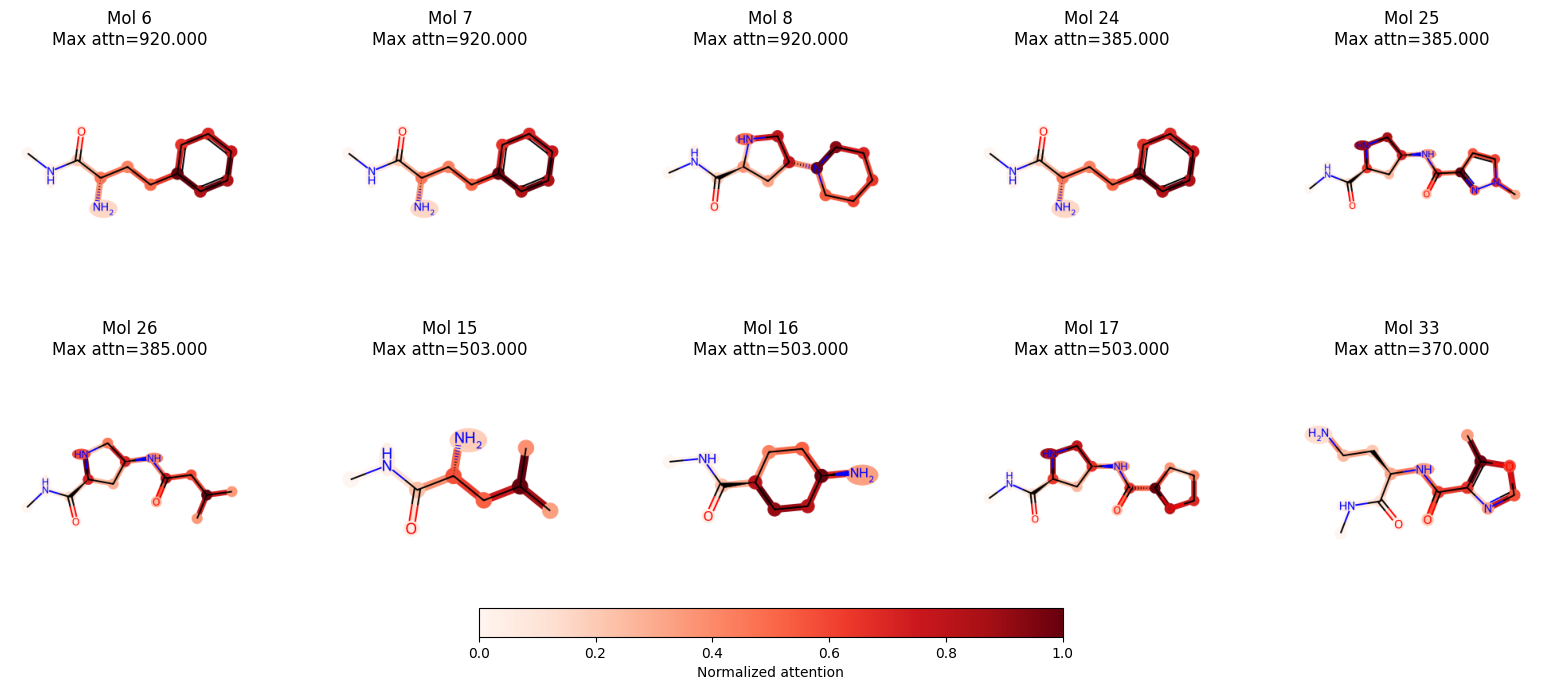

In [258]:
# Visualize top 5 molecules for synthon 0, last GAT layer
visualize_top_attention(flat_attention_list, dataset, syn_idx=0, top_n=10, layer_idx=-1)

The above is only a emall example as we're only training on 1000 molecules. But in principle, visualising the attention weights from the transformer has the following purpose:

- A GAT computes a representation for each node by attending to its neighbors.
- Attention weights (α) tell you how much the model "focuses" on each bond/neighbor when updating a node’s representation.

For each bond (i, j) in the molecule, the GAT computes a weight between 0 and 1 (after normalization).

- A **high attention weight** means the model considers that bond more important for predicting the property of interest (in this case, enrichment = activity).
- A **low weight** means the model thinks it’s less informative.

### Mapping synthons to complete synthesised molecules.

In [252]:
from rdkit import Chem
from rdkit.Chem import Draw
import torch
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap

def highlight_synthon_in_molecule(dataset, attention_list, mol_idx, syn_idx=0, layer_idx=-1, img_size=(300, 300)):
    """
    Highlight a synthon substructure inside the full molecule with attention weights.
    
    Parameters
    ----------
    dataset : MultiSynthonDELDataset
        Your dataset with 'smiles' for full molecules and 'synthon_graphs'.
    attention_list : list
        flat_attention_list[i][syn_idx] -> (edge_index, alpha)
    mol_idx : int
        Which molecule to visualize
    syn_idx : int
        Which synthon (0,1,2)
    layer_idx : int
        Which GAT layer (-1 for last)
    img_size : tuple
        Output image size
    
    Returns
    -------
    img : PIL.Image.Image
        Image of the full molecule with the synthon highlighted.
    """
    # 1. Get full molecule SMILES
    full_smiles = dataset.data_list[mol_idx].get('final_smiles')
    if full_smiles is None:
        raise ValueError(f"Full molecule SMILES not found for molecule index {mol_idx}")
    
    mol = Chem.MolFromSmiles(full_smiles)
    if mol is None:
        raise ValueError(f"RDKit could not parse SMILES: {full_smiles}")
    
    # 2. Get attention for this synthon
    edge_index, alpha = attention_list[mol_idx][syn_idx]
    if alpha.ndim == 2:
        alpha = alpha.mean(dim=1)
    
    # 3. Normalize attention for coloring
    if len(alpha) > 0:
        min_val, max_val = alpha.min().item(), alpha.max().item()
        norm_alpha = (alpha - min_val) / (max_val - min_val + 1e-8)
    else:
        norm_alpha = alpha
    
    # Convert edge_index to standard (2 x N) if needed
    if isinstance(edge_index, torch.Tensor):
        if edge_index.ndim == 2 and edge_index.shape[0] == 2:
            edge_pairs = edge_index.t().tolist()
        elif edge_index.ndim == 1:
            # Try to infer 2 x N shape
            if edge_index.numel() % 2 != 0:
                raise ValueError(f"Cannot reshape edge_index of length {edge_index.numel()} into 2 x N")
            edge_index_2d = edge_index.view(2, -1)
            edge_pairs = edge_index_2d.t().tolist()
        else:
            raise ValueError(f"Unexpected edge_index tensor shape: {edge_index.shape}")
    elif isinstance(edge_index, (list, tuple)):
        if len(edge_index) > 0 and isinstance(edge_index[0], (list, tuple)):
            edge_pairs = edge_index
        else:
            raise ValueError(f"Unexpected edge_index list/tuple format: {edge_index[:10]} ...")
    else:
        raise TypeError(f"edge_index has unsupported type: {type(edge_index)}")
    
    # 5. Map attention to bonds in full molecule
    bond_attn = {}
    for idx, (i, j) in enumerate(edge_pairs):
        bond = mol.GetBondBetweenAtoms(i, j)
        if bond is not None:
            bond_attn[bond.GetIdx()] = norm_alpha[idx].item()
    
    # Normalize bond attention to [0,1] (again, in case of sparse edges)
    if len(bond_attn) > 0:
        min_b, max_b = min(bond_attn.values()), max(bond_attn.values())
        bond_colors = {k: (v - min_b) / (max_b - min_b + 1e-8) for k, v in bond_attn.items()}
    else:
        bond_colors = {}
    
    # Atom colors: sum of connected bond attentions
    atom_colors = {i: 0.0 for i in range(mol.GetNumAtoms())}
    for bond_idx, weight in bond_colors.items():
        bond = mol.GetBondWithIdx(bond_idx)
        atom_colors[bond.GetBeginAtomIdx()] += weight
        atom_colors[bond.GetEndAtomIdx()] += weight
    if len(atom_colors) > 0:
        max_atom_val = max(atom_colors.values())
        atom_colors = {k: v/max_atom_val for k, v in atom_colors.items()}
    
    # 6. Draw molecule with attention colors
    cmap = get_cmap("Reds")
    Draw.rdMolDraw2D.PrepareMolForDrawing(mol)
    drawer = Draw.MolDraw2DCairo(img_size[0], img_size[1])
    drawer.DrawMolecule(
        mol,
        highlightAtoms=list(atom_colors.keys()),
        highlightBonds=list(bond_colors.keys()),
        highlightBondColors={k: cmap(v)[:3] for k,v in bond_colors.items()},
        highlightAtomColors={k: cmap(v)[:3] for k,v in atom_colors.items()}
    )
    drawer.FinishDrawing()
    img = drawer.GetImage()
    
    return img


In [253]:
img = highlight_synthon_in_molecule(dataset, flat_attention_list, mol_idx=6, syn_idx=0)
plt.imshow(img)
plt.axis('off')
plt.show()


ValueError: Cannot reshape edge_index of length 2973 into 2 x N

In [259]:
# If each synthon entry is just a tensor of edges, what about the alpha/attention values?
mol_att = flat_attention_list[mol_idx][syn_idx]  # tensor of shape [2, num_edges]
print(mol_att.dtype)

torch.int64
